# Mastering Unsupervised Learning: Clustering Techniques

## 1. Data Preparation
We start by loading our customer data and cleaning the column names for easier access.

In [1]:
# !pip install seaborn scipy scikit-learn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

# Load dataset
df = pd.read_csv('../data/customers.csv')
df.columns = ['customer_id', 'gender', 'age', 'income', 'spending_score']
df=df[['age','spending_score']]
df.head()

,age,spending_score
0,19,39
1,21,81
2,20,6
3,23,77
4,31,40


In [4]:
X=df.values
my_kmeans = KMeans(n_clusters=3)
my_kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


## 2. Finding the Optimal K: 
### 2.1 The Elbow Method
The **Elbow Method** looks at the total **Inertia** (sum of squared errors). We look for the "elbow" point where adding another cluster doesn't significantly reduce the error.

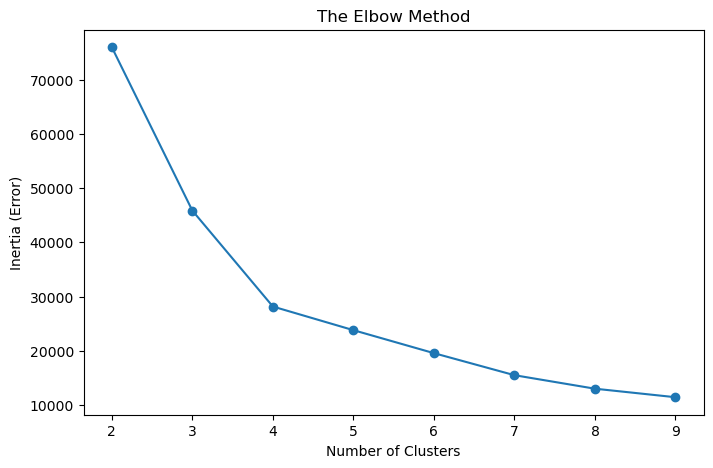

Based on the plot, the 'Elbow' appears at K=4.


In [5]:
errors = []
X = df[['age', 'spending_score']].values

for n in range(2, 10):
    my_kmeans = KMeans(n_clusters=n, random_state=0, n_init=10)
    my_kmeans.fit(X)
    errors.append(my_kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), errors, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Error)')
plt.show()

print("Based on the plot, the 'Elbow' appears at K=4.")

In [6]:
from kneed import KneeLocator
K=range(2, 10)
kneedle = KneeLocator(K, errors, curve='convex', direction='decreasing')
optimal_k = kneedle.knee
print("Optimal number of clusters:", optimal_k)

Optimal number of clusters: 4


### 2.2 Validating with Silhouette Score
The **Silhouette Score** measures how similar an object is to its own cluster compared to others.
* **Close to 1:** Well-separated clusters.
* **Close to 0:** Overlapping clusters.
* **Negative:** Likely assigned to the wrong cluster.

In [7]:
s_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X)
    score = silhouette_score(X, kmeans.labels_)
    s_scores.append(score)

optimal_k = np.argmax(s_scores) + 2
print(f"Optimal number of clusters based on Silhouette Score: {optimal_k}")

Optimal number of clusters based on Silhouette Score: 4


### 2.3 Stability-based method

- Answer a very practical question:  `“If I slightly change my data, do I get the same clusters?”`
    - If yes → your clustering (and k) is reliable
    - If no → your clusters are probably arbitrary

- **Core idea:**
    1. Perturb the dataset (resample / add noise)
    2. Re-run clustering
    3. Compare cluster assignments across runs
    4. **Good k = high consistency (stability)**
- Pick the k with highest stability score

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def stability_score(X, k, runs=10):

    # Run clustering on multiple samples using same k 
    labels_list = []
    for _ in range(runs):
        idx = np.random.choice(len(X), int(0.8 * len(X)), replace=False)
        X_sample = X[idx]

        labels = KMeans(n_clusters=k, n_init=10).fit_predict(X_sample)
        labels_list.append((idx, labels))

    # Find the scores of each run then calculate the stability
    scores = []
    for i in range(len(labels_list)):
        for j in range(i+1, len(labels_list)):
            idx1, lab1 = labels_list[i]
            idx2, lab2 = labels_list[j]

            common = set(idx1).intersection(idx2)

            if len(common) > 0:
                lab1_map = {idx1[t]: lab1[t] for t in range(len(idx1))}
                lab2_map = {idx2[t]: lab2[t] for t in range(len(idx2))}

                l1 = [lab1_map[c] for c in common]
                l2 = [lab2_map[c] for c in common]

                scores.append(adjusted_rand_score(l1, l2)) # Do these two clusterings group the same points together?

    return np.mean(scores)

In [13]:
# Run Stability Across k

X_values = df[['age', 'spending_score']].values
k_values = range(2, 10)
stability_scores = []

for k in k_values:
    score = stability_score(X_values, k)
    stability_scores.append(score)
    print(f"k={k}, stability={score:.4f}")

k=2, stability=0.9244
k=3, stability=0.9696
k=4, stability=0.9783
k=5, stability=0.7098
k=6, stability=0.6922
k=7, stability=0.7658
k=8, stability=0.8265
k=9, stability=0.8019


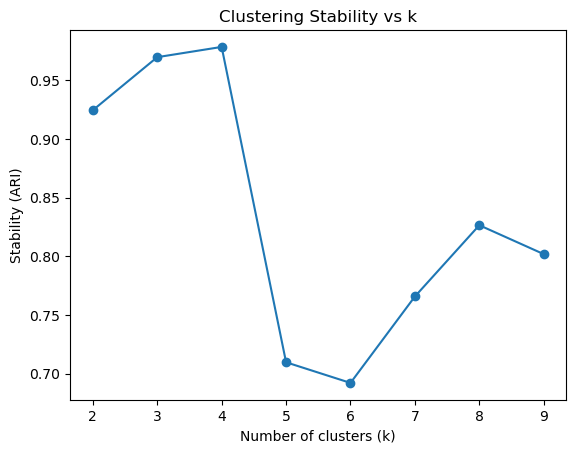

In [14]:
# Plot Results

plt.plot(k_values, stability_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Stability (ARI)")
plt.title("Clustering Stability vs k")
plt.show()

## 4. Final K-Means Model & Visualization
We now run the model with K=4 and visualize the results and their centers (centroids).


In [15]:
final_kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
df['clusters'] = final_kmeans.fit_predict(X)

In [16]:
df

,age,spending_score,clusters
0,19,39,3
1,21,81,1
2,20,6,2
3,23,77,1
4,31,40,3
...,...,...,...
195,35,79,1
196,45,28,2
197,32,74,1
198,32,18,2


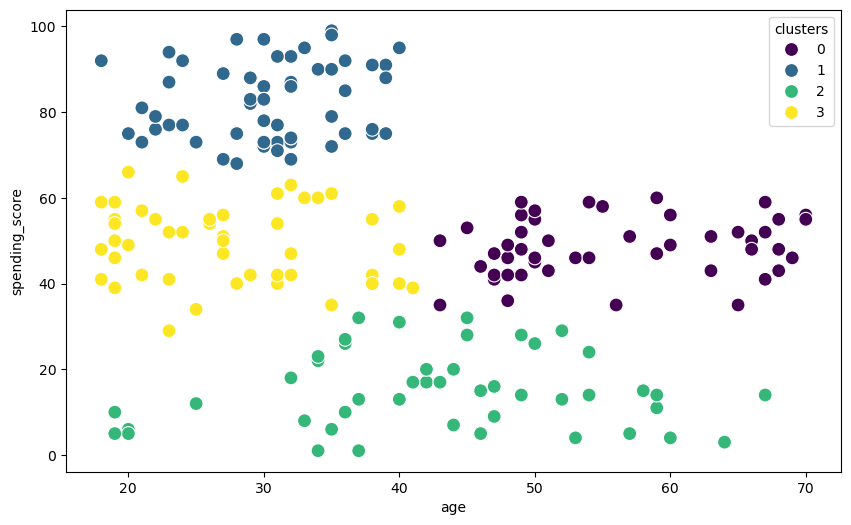

In [17]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='spending_score', hue='clusters', palette='viridis', s=100);

In [18]:
# Plotting Centers
centers = final_kmeans.cluster_centers_
centers

array([[55.70833333, 48.22916667],
       [30.1754386 , 82.35087719],
       [43.29166667, 15.02083333],
       [27.61702128, 49.14893617]])

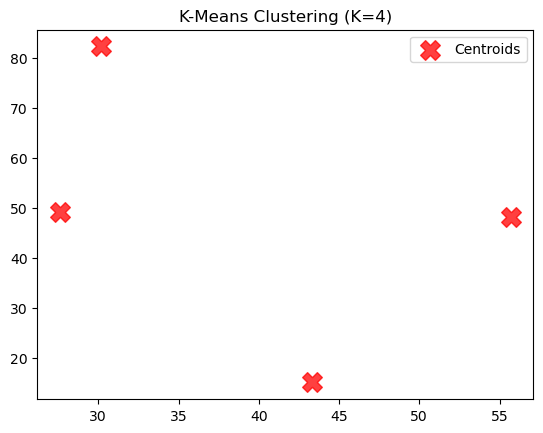

In [19]:
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')
plt.title("K-Means Clustering (K=4)")
plt.legend()
plt.show()

In [23]:
df

,age,spending_score,clusters
0,19,39,3
1,21,81,1
2,20,6,2
3,23,77,1
4,31,40,3
...,...,...,...
195,35,79,1
196,45,28,2
197,32,74,1
198,32,18,2


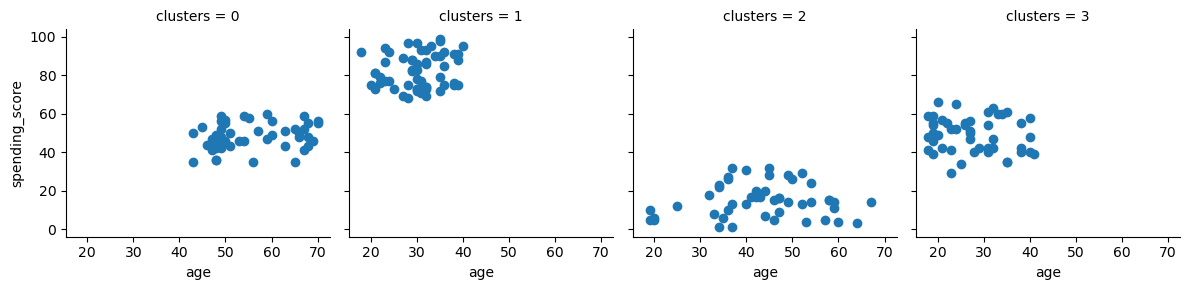

In [24]:
sns.FacetGrid(data=df, col='clusters').map(plt.scatter, 'age', 'spending_score');

### Business Conclusions
By segmenting the data, we can identify four distinct customer personas:
1. **Cluster 0:** Middle-age customers with low spending.
2. **Cluster 1:** Young customers with high spending.
3. **Cluster 2:** Young customers with moderate spending.
4. **Cluster 3:** Senior customers with moderate spending.

## 5. Hierarchical Clustering & Dendrograms
Hierarchical clustering builds a tree of clusters. We use **Ward's Linkage**, which minimizes the variance (ESS) when merging clusters.

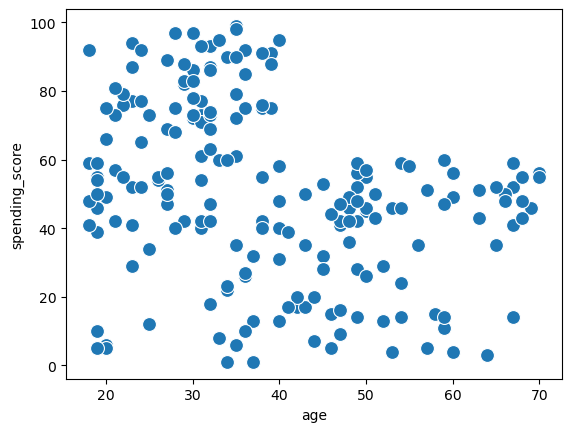

In [25]:
sns.scatterplot(data=df, x='age', y='spending_score', s=100);

In [26]:
# Agglomoritve Clustering (Bottom-Up)
from sklearn.cluster import AgglomerativeClustering
my_agg= AgglomerativeClustering(4)
my_agg.fit(df)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",4
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


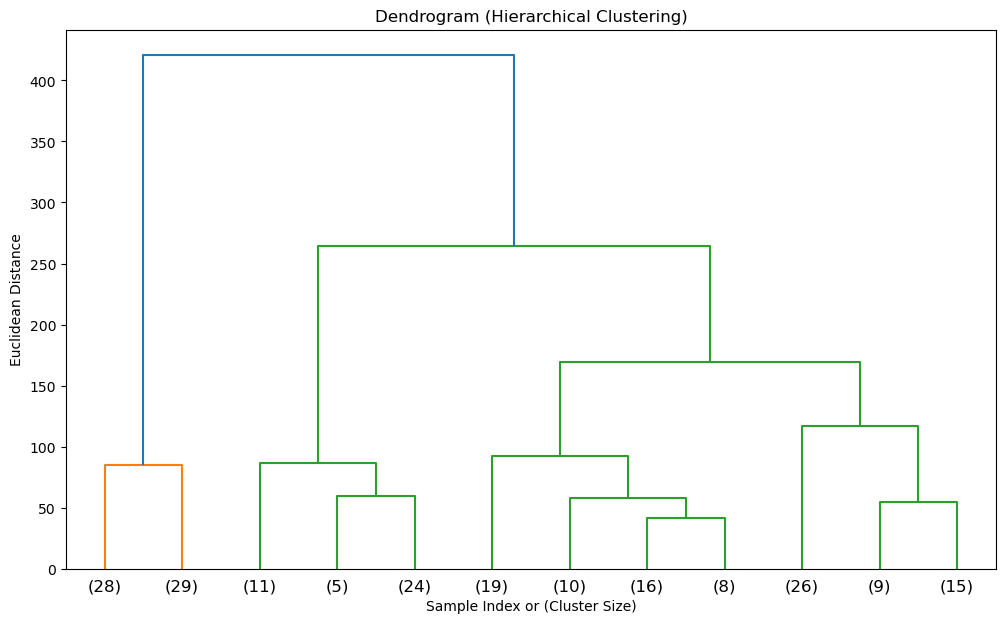

In [27]:
# Create Linkage Matrix
from scipy.cluster.hierarchy import linkage, dendrogram
my_lnk = linkage(X, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(my_lnk, orientation='top', truncate_mode='lastp', p=12)
plt.title('Dendrogram (Hierarchical Clustering)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Euclidean Distance')
plt.show()

## 6. Dimensionality Reduction

### 6.1 PCA 

- Principal Component Analysis (PCA) is a technique used to reduce the number of features in a dataset while preserving as much information (variance) as possible.

- Instead of using the original variables directly, PCA creates new variables called principal components:
    - 1st principal component = direction with the most variance
    - 2nd principal component = next-most variance, orthogonal to the first
    - 3rd principal component = next-most variance, orthogonal to the first two
    - and so on


**Typical goals of PCA:**

    - Reduce dimensionality
    - Remove redundant / correlated features
    - Speed up models
    - Visualize high-dimensional data in 2D or 3D
    - Reduce noise


<center><img src='https://raw.githubusercontent.com/ha2285/files/refs/heads/main/PCA.gif'></center>

In [30]:
# Example using iris data
from sklearn.datasets import load_iris
data=load_iris().data
data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

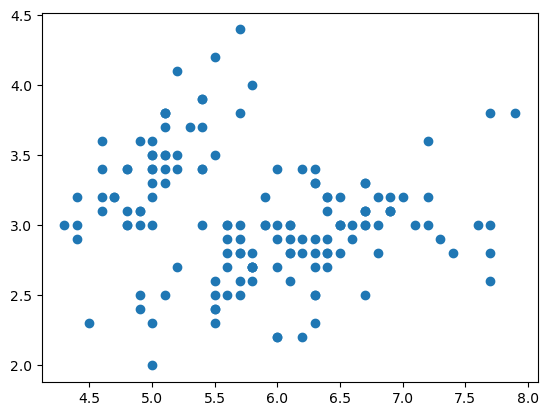

In [31]:
plt.scatter(data[:,0],data[:,1]);

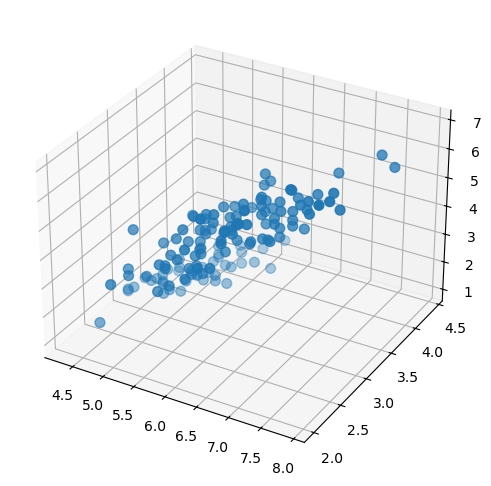

In [32]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter3D(data[:,0], data[:,1], data[:,2], s=50);

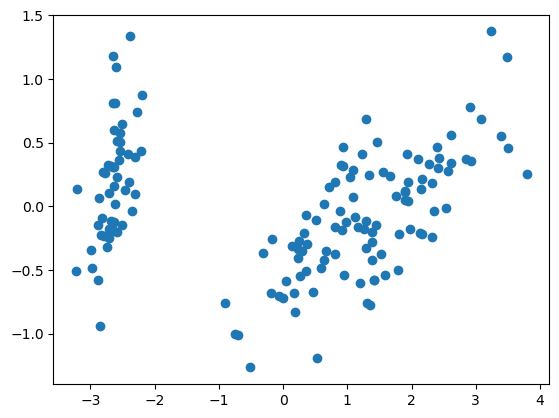

In [33]:
# PCA Example
from sklearn.decomposition import PCA
my_pca= PCA(n_components=2)
new_data=my_pca.fit_transform(data)
plt.scatter(new_data[:,0],new_data[:,1]);

### 6.2 t-SNE

- t-SNE (t-Distributed Stochastic Neighbor Embedding) is a nonlinear dimensionality reduction technique mainly used for visualization of high-dimensional data in 2D or 3D.
- Unlike PCA, which tries to preserve overall variance, t-SNE focuses on preserving the neighborhood around each point:
    - Points that are close in the original space stay close
    - Distant points may not preserve their exact distances

<center><img src='https://raw.githubusercontent.com/ha2285/files/refs/heads/main/t-sne.png' width=600></center>

For each point $(x_i)$:

1. Treat $(x_i)$ as the current point.
3. Compute how close every other point $(x_j)$ is to it
4. Create neighbor probabilities $(p_{j|i})$
5. Try to place that point in low-dimensional space so its nearby neighbors stay nearby


For example, with 100 samples:

- Point 1 asks: “Which points are closest to me?”
- Point 2 asks the same
- ...
- Point 100 asks the same

Then t-SNE finds a 2D layout that best satisfies all of those neighborhood relationships simultaneously.



This makes t-SNE very good for finding clusters or groups visually.


| PCA                          | t-SNE                      |
| ---------------------------- | -------------------------- |
| Linear                       | Nonlinear                  |
| Preserves variance           | Preserves local similarity |
| Fast                         | Slower                     |
| Good for preprocessing       | Good for visualization     |
| Components are interpretable | Axes are not interpretable |


In practice, many people do:     `Data → PCA → t-SNE`  because PCA removes noise and makes t-SNE faster.


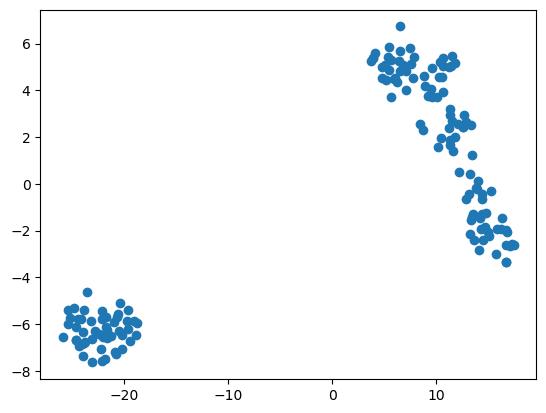

In [34]:
# TSNE Example
from sklearn.manifold import TSNE
my_tsne = TSNE(n_components=2,init='pca')
new_data=my_tsne.fit_transform(data)
plt.scatter(new_data[:,0],new_data[:,1]);